In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics 


In [378]:
#data collection and analysis

#loading the dataset from csv files to pandas dataset
big_mart_data = pd.read_csv('/Users/asankawijesooriya/Movies/Community-Project/backend/data/Train.csv')


In [379]:
big_mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [380]:
#number of data points and features
big_mart_data.shape


(8523, 12)

In [381]:
big_mart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [382]:
#checking for missing values
big_mart_data.isnull().sum()    

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [383]:
#mean - avaeage value 
#mode - most repeated value


In [384]:
#mean value items waight column
big_mart_data['Item_Weight'].mean() #12.857

12.857645184135976

In [385]:
# filling the missing values with mean

big_mart_data['Item_Weight'] = big_mart_data['Item_Weight'].fillna(
big_mart_data['Item_Weight'].mean()
)
big_mart_data.isnull().sum() #0

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [386]:
#replacing missing values in outlet size with mode
mode_of_outlet_size = big_mart_data.pivot_table(values='Outlet_Size', index='Outlet_Type', aggfunc=(lambda x: x.mode()[0]))
print(mode_of_outlet_size)

                  Outlet_Size
Outlet_Type                  
Grocery Store           Small
Supermarket Type1       Small
Supermarket Type2      Medium
Supermarket Type3      Medium


In [387]:
missing_values = big_mart_data['Outlet_Size'].isnull()

In [388]:
print(missing_values)

0       False
1       False
2       False
3        True
4       False
        ...  
8518    False
8519     True
8520    False
8521    False
8522    False
Name: Outlet_Size, Length: 8523, dtype: bool


In [389]:
# Step 1: Find missing values
missing_values = big_mart_data['Outlet_Size'].isnull()

# Step 2: Replace ONLY missing values with mode (keeping non-null values unchanged)
big_mart_data.loc[missing_values, 'Outlet_Size'] = mode_of_outlet_size

# Verify the replacement
print("Null values after replacement:", big_mart_data['Outlet_Size'].isnull().sum())
print("Value counts:\n", big_mart_data['Outlet_Size'].value_counts())

Null values after replacement: 2410
Value counts:
 Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64


In [390]:
big_mart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [391]:
print("Number of missing values:", missing_values.sum())
print(missing_values.head())  # Should show True/False for nulls

Number of missing values: 2410
0    False
1    False
2    False
3     True
4    False
Name: Outlet_Size, dtype: bool


In [392]:
big_mart_data.isnull().sum() #0

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [393]:
# data analysis
#statistical measures of the dataset
big_mart_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [394]:
sns.set()

2 plt. figure(figsize=(6,6))
3 sns.distplot(big_mart_data["Item_Weight'])
4 plt. show()

In [395]:
plt. figure(figsize=(6,6))


<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

/var/folders/0x/npz908g526j7xjjw_88kbrr80000gn/T/ipykernel_3955/2229186239.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(big_mart_data["Item_Weight"])


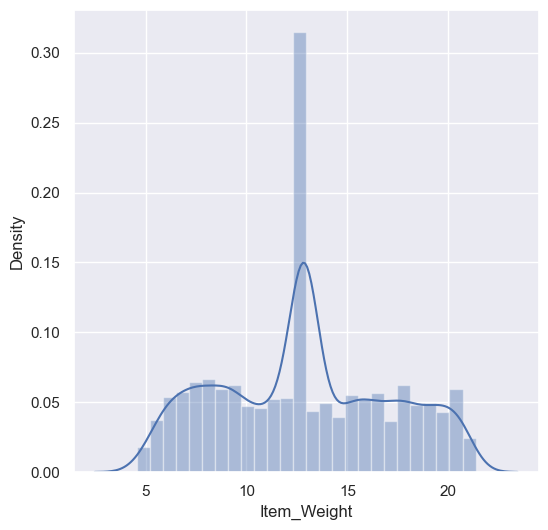

In [396]:
plt.figure(figsize=(6,6))
sns.distplot(big_mart_data["Item_Weight"])
plt.show()

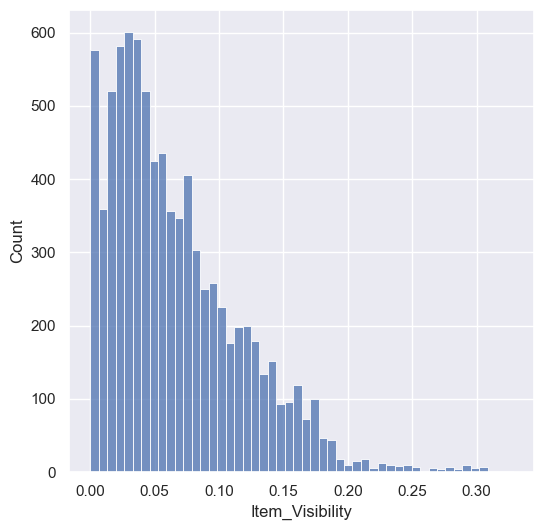

In [397]:
# Item Visibility distribution
plt.figure(figsize=(6,6))
sns.histplot(big_mart_data['Item_Visibility'])
plt.show()  # Removed extra space before 'show'

/var/folders/0x/npz908g526j7xjjw_88kbrr80000gn/T/ipykernel_3955/1610987680.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(big_mart_data['Item_MRP'])


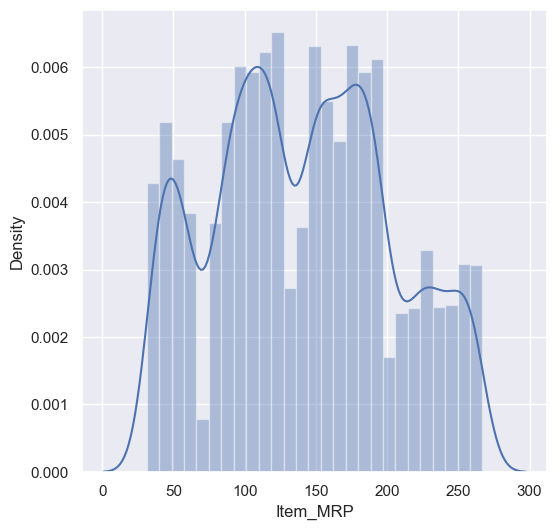

In [398]:
# Item MRP distribution
plt.figure(figsize=(6,6))
sns.distplot(big_mart_data['Item_MRP'])
plt.show()

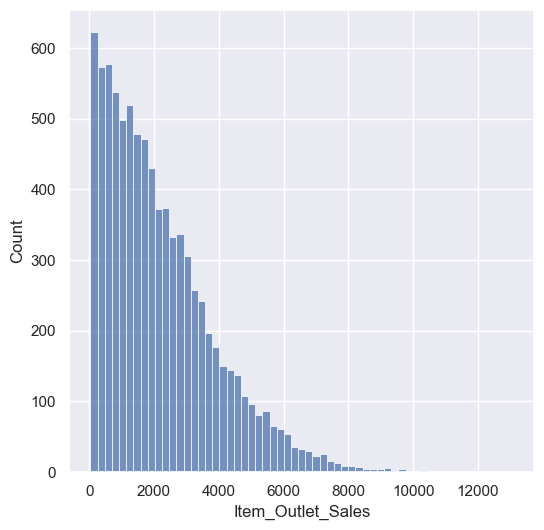

In [399]:
# Item Outlet Sales distribution
plt.figure(figsize=(6,6))
sns.histplot(big_mart_data['Item_Outlet_Sales'])
plt.show()

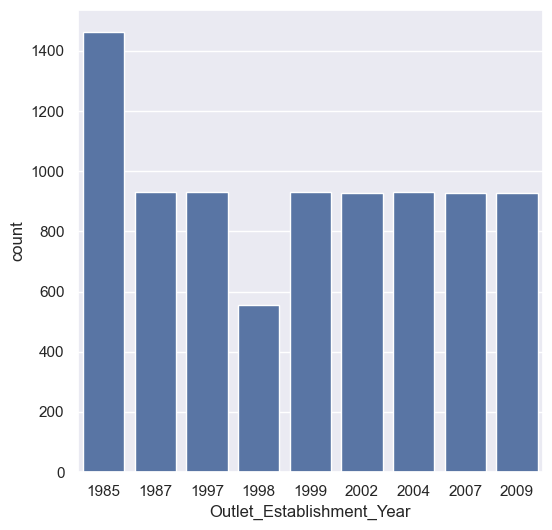

In [400]:
# Outlet Establishment Year distribution
plt.figure(figsize=(6,6))
sns.countplot(x='Outlet_Establishment_Year', data=big_mart_data)
plt.show()

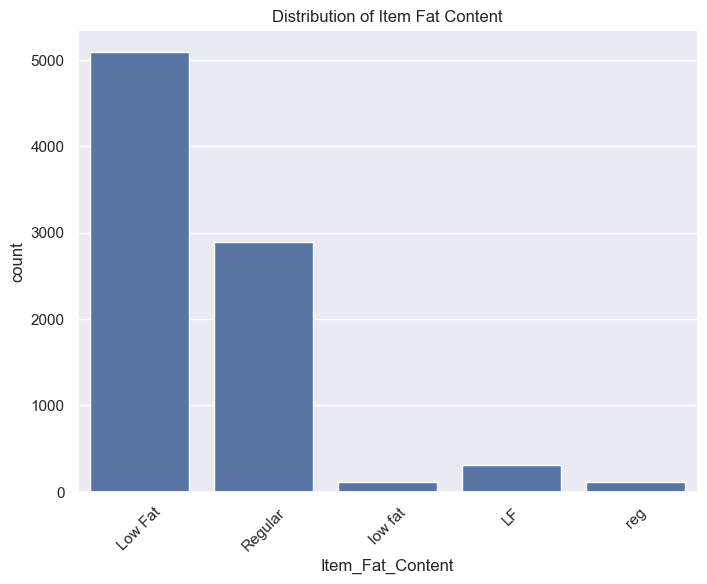

In [401]:
# Item_Fat_Content distribution
plt.figure(figsize=(8,6))  # Slightly wider for better label spacing
sns.countplot(x='Item_Fat_Content', data=big_mart_data)
plt.xticks(rotation=45)  # Rotate labels if they're long
plt.title('Distribution of Item Fat Content')  # Add descriptive title
plt.show()

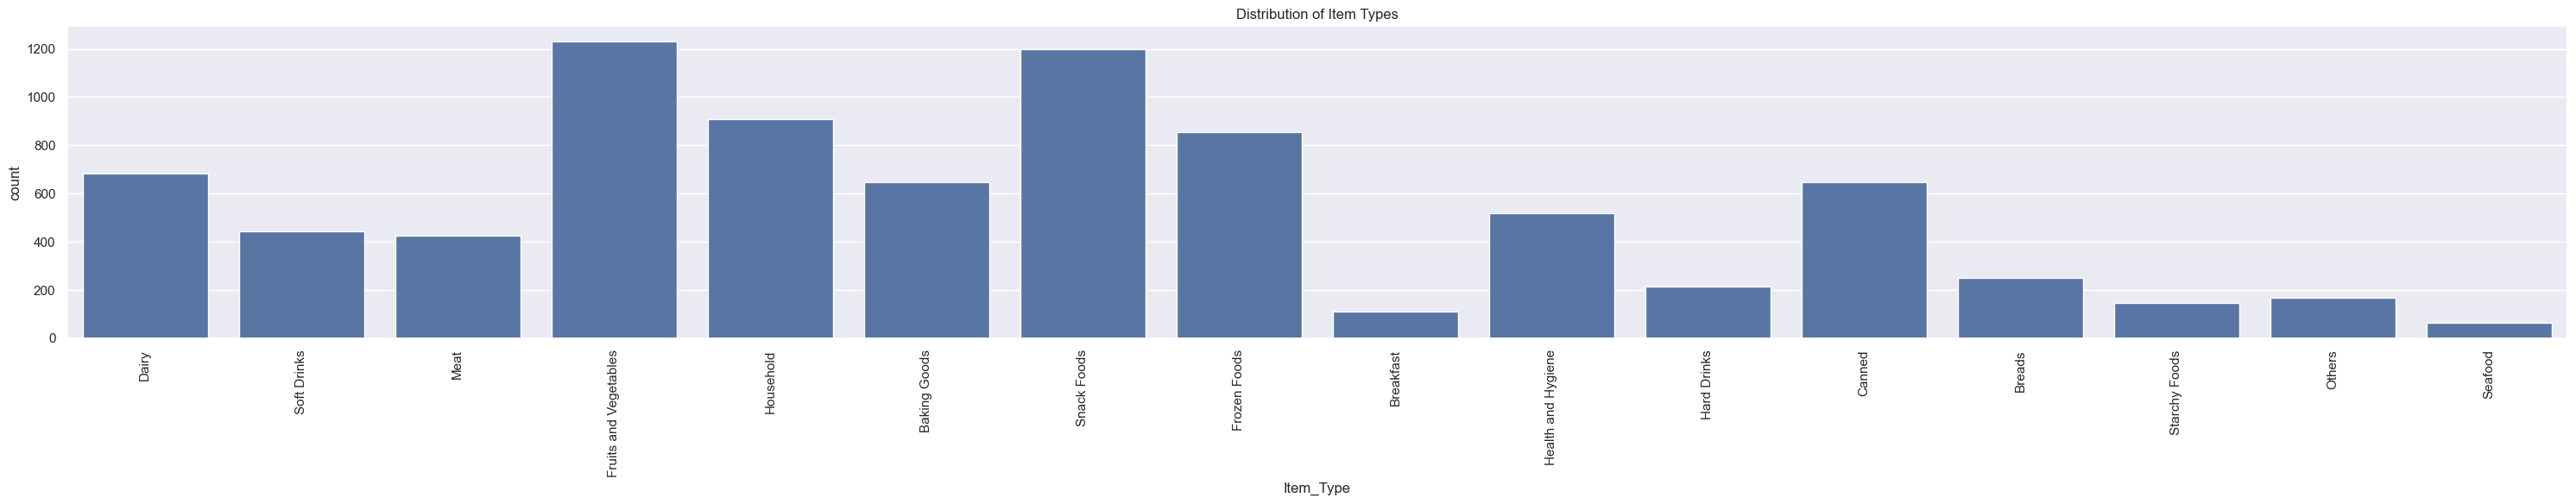

In [402]:
# Item_Type distribution
plt.figure(figsize=(30,6))
sns.countplot(x='Item_Type', data=big_mart_data)
plt.xticks(rotation=90)  # Rotate labels vertically for readability
plt.title('Distribution of Item Types')
plt.tight_layout()  # Adjust layout to prevent label cutoff
plt.show()

In [403]:
print(big_mart_data['Outlet_Size'].head())


0    Medium
1    Medium
2    Medium
3       NaN
4      High
Name: Outlet_Size, dtype: object


In [404]:
print(big_mart_data['Outlet_Size'].value_counts())

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64


In [405]:
print(big_mart_data['Outlet_Size'].isnull().sum())


2410


In [406]:

# Check data type
print(big_mart_data['Outlet_Size'].dtype)


object


In [407]:
print(big_mart_data['Outlet_Size'].head())
print(big_mart_data['Outlet_Size'].apply(type).value_counts())

0    Medium
1    Medium
2    Medium
3       NaN
4      High
Name: Outlet_Size, dtype: object
Outlet_Size
<class 'str'>      6113
<class 'float'>    2410
Name: count, dtype: int64


In [408]:
# If the column contains DataFrames, extract the first value
big_mart_data['Outlet_Size'] = big_mart_data['Outlet_Size'].apply(lambda x: x.iloc[0] if isinstance(x, pd.DataFrame) else x)

In [409]:
big_mart_data['Outlet_Size'] = big_mart_data['Outlet_Size'].astype(str)  # Force string conversion
# OR
big_mart_data['Outlet_Size'] = big_mart_data['Outlet_Size'].astype('category')  # Convert to categorical

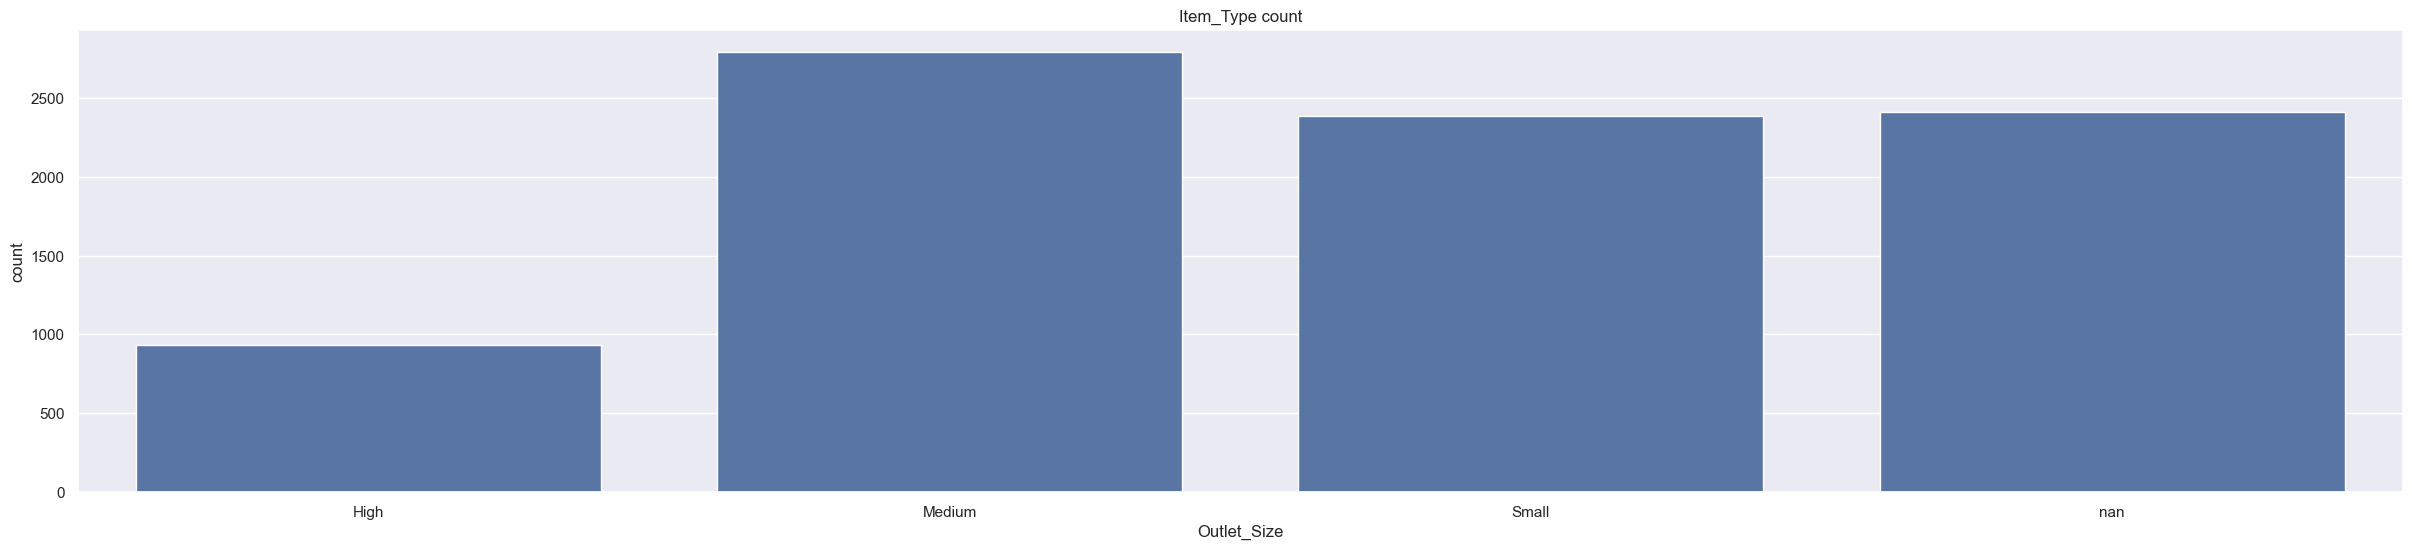

In [410]:
# Outlet_Size column
plt.figure(figsize=(30,6))
sns.countplot(x='Outlet_Size', data=big_mart_data)
plt.title('Item_Type count')
plt.show()

In [411]:
#data preprocessing
big_mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,nan,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [412]:
big_mart_data['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [413]:
big_mart_data.replace({'Item_Fat_Content': {'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'}}, inplace=True)

In [414]:
big_mart_data[ 'Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [415]:
#label encoding 
encoder = LabelEncoder()

In [416]:
big_mart_data['Item_Identifier'] = encoder.fit_transform(big_mart_data['Item_Identifier'])
big_mart_data['Item_Fat_Content'] = encoder.fit_transform(big_mart_data['Item_Fat_Content'])
big_mart_data['Item_Type'] = encoder.fit_transform(big_mart_data['Item_Type'])
big_mart_data['Outlet_Identifier'] = encoder.fit_transform(big_mart_data['Outlet_Identifier'])
big_mart_data['Outlet_Size'] = encoder.fit_transform(big_mart_data['Outlet_Size'])


big_mart_data['Outlet_Location_Type'] = encoder.fit_transform(big_mart_data['Outlet_Location_Type'])
big_mart_data['Outlet_Type'] = encoder.fit_transform(big_mart_data['Outlet_Type'])

In [417]:
big_mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,156,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,8,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,662,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,1121,19.20,1,0.000000,6,182.0950,0,1998,3,2,0,732.3800
4,1297,8.93,0,0.000000,9,53.8614,1,1987,0,2,1,994.7052


In [418]:
big_mart_data= big_mart_data.drop(['Item_Identifier' ,'Outlet_Identifier'], axis=1)  # axis=1 for columns

In [419]:
big_mart_data.head()


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.30,0,0.016047,4,249.8092,1999,1,0,1,3735.1380
1,5.92,1,0.019278,14,48.2692,2009,1,2,2,443.4228
2,17.50,0,0.016760,10,141.6180,1999,1,0,1,2097.2700
3,19.20,1,0.000000,6,182.0950,1998,3,2,0,732.3800
4,8.93,0,0.000000,9,53.8614,1987,0,2,1,994.7052


In [420]:
X = big_mart_data.drop(columns='Item_Outlet_Sales', axis=1)
Y = big_mart_data['Item_Outlet_Sales']

In [421]:
print(X)

      Item_Weight  Item_Fat_Content  ...  Outlet_Location_Type  Outlet_Type
0           9.300                 0  ...                     0            1
1           5.920                 1  ...                     2            2
2          17.500                 0  ...                     0            1
3          19.200                 1  ...                     2            0
4           8.930                 0  ...                     2            1
...           ...               ...  ...                   ...          ...
8518        6.865                 0  ...                     2            1
8519        8.380                 1  ...                     1            1
8520       10.600                 0  ...                     1            1
8521        7.210                 1  ...                     2            2
8522       14.800                 0  ...                     0            1

[8523 rows x 9 columns]


In [422]:
print(Y)

0       3735.1380
1        443.4228
2       2097.2700
3        732.3800
4        994.7052
          ...    
8518    2778.3834
8519     549.2850
8520    1193.1136
8521    1845.5976
8522     765.6700
Name: Item_Outlet_Sales, Length: 8523, dtype: float64


spliting the data into training.testing data

In [423]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2,random_state=2)

In [424]:
print(X.shape, X_train.shape, X_test. shape)

(8523, 9) (6818, 9) (1705, 9)


In [425]:
# machine lerning model training



XBoost Regressor

In [426]:
# Initialize XGBoost Regressor (with hyperparameters)
regressor = XGBRegressor(
    colsample_bytree= 0.6,
    learning_rate=0.01,  # Step size shrinkage
    max_depth=3,       # Max tree depth
    random_state=42,
    subsample=1.0,  # Fraction of samples to be used for each tree
)

# Fit the model

In [427]:
regressor.fit(X_train, Y_train) 

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [428]:
# prediction on training data
training_data_prediction = regressor.predict(X_train)

In [429]:
1 # R squared Value
r2_train = metrics.r2_score(Y_train, training_data_prediction)

In [430]:
print('R Squared value = ', r2_train)

R Squared value =  0.4139530346623381


In [431]:
#predict tesrt data

test_data_prediction = regressor.predict(X_test)

In [432]:
print(test_data_prediction)

[2254.4285 2773.3477 1897.1095 ... 2576.0562 2808.8828 2832.2346]


In [433]:
# R squared Value
r2_test = metrics.r2_score(Y_test, test_data_prediction)

In [434]:
print('R Squared value = ', r2_test)

R Squared value =  0.39487769136299167


In [435]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(n_estimators=6818),
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

grid_search.fit(X_train, Y_train)
best_params = grid_search.best_params_

KeyboardInterrupt: 

In [ ]:
print(best_params)

{'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 1.0}
